# Transport vs Animal Classification

Real rocket, cat and horse images.

## Step 1: Import libraries

This cell imports image, numerical, visualization and machine-learning tools.

In [22]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


## Step 2: Locate the included real-image dataset

Each folder name is treated as one class.

In [23]:
DATASET_DIR=Path("../datasets/01_transport_vs_animal")
print([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])

['animal', 'transport']


## Step 3: Load and resize images

Traditional ML needs consistent image dimensions.

In [24]:
def load_images(path, size=(128,128)):
    images, labels = [], []
    for class_dir in sorted(path.iterdir()):
        if class_dir.is_dir():
            for fp in sorted(class_dir.glob("*.png")):
                images.append(np.array(Image.open(fp).convert("RGB").resize(size)))
                labels.append(class_dir.name)
    return np.array(images), np.array(labels)

images,labels=load_images(DATASET_DIR)
print(images.shape,labels.shape)

(56, 128, 128, 3) (56,)


## Step 4: Display real image samples

This verifies the dataset.

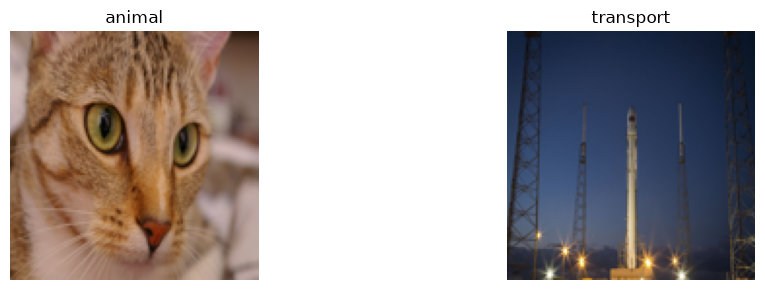

In [25]:
classes=sorted(set(labels))
plt.figure(figsize=(12,3))
for i,name in enumerate(classes,1):
    idx=np.where(labels==name)[0][0]
    plt.subplot(1,len(classes),i); plt.imshow(images[idx]); plt.title(name); plt.axis("off")
plt.tight_layout(); plt.show()


## Step 5: Extract features

HOG captures object shape and edge direction.

In [26]:
from skimage.feature import hog
def hog_feat(im):
    gray=np.mean(im,axis=2)/255.0
    return hog(gray,orientations=9,pixels_per_cell=(16,16),cells_per_block=(2,2),block_norm="L2-Hys")
features=np.array([hog_feat(im) for im in images])
print(features.shape)


(56, 1764)


## Step 6: Split train and test sets

The test set remains unseen during training.

In [27]:
X_train,X_test,y_train,y_test=train_test_split(features,labels,test_size=.25,random_state=42,stratify=labels)
print("Train:",len(X_train),"Test:",len(X_test))


Train: 42 Test: 14


## Step 7: Train the model

SVM learns a separating boundary.

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
model=make_pipeline(StandardScaler(),SVC(C=5))
model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U9](2,)","['animal','transport']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1764
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## Step 8: Evaluate

We use accuracy, classification report and confusion matrix.

Accuracy: 1.0
              precision    recall  f1-score   support

      animal       1.00      1.00      1.00         7
   transport       1.00      1.00      1.00         7

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



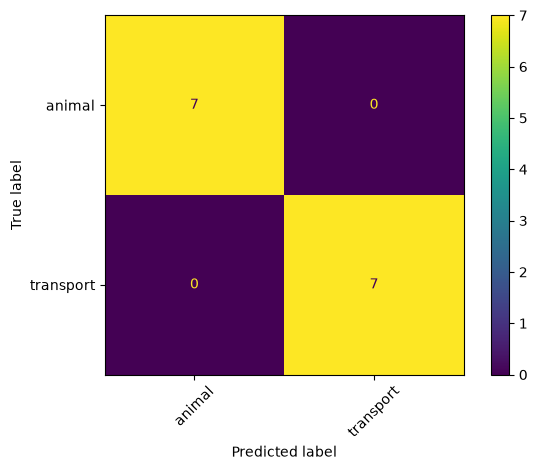

In [29]:
pred=model.predict(X_test)
print("Accuracy:",round(accuracy_score(y_test,pred),4))
print(classification_report(y_test,pred))
ConfusionMatrixDisplay.from_predictions(y_test,pred,xticks_rotation=45)
plt.tight_layout(); plt.show()


## Conclusion

Workflow: real images → preprocessing → feature extraction → traditional ML → evaluation.

# Test One Single Image

This section tests one individual animal or transport image after the SVM model has been trained.

The image is opened, converted to RGB, resized to 128 × 128, converted into a NumPy array, transformed into HOG features, reshaped into one sample and passed to the trained model.

In [30]:
sample_index = 2

single_test_features = X_test[sample_index].reshape(1, -1)

predicted_class = model.predict(
    single_test_features
)[0]

actual_class = y_test[sample_index]

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)

Actual class: transport
Predicted class: transport


Single image
    ↓
Resize
    ↓
Convert to NumPy
    ↓
Extract LBP
    ↓
Reshape to one row
    ↓
SVM prediction

In [32]:
probabilities = model.predict_proba(
    single_image_features
)[0]

class_labels = model.classes_

for label, probability in zip(
    class_labels,
    probabilities
):
    print(
        f"{label}: {probability * 100:.2f}%"
    )

AttributeError: This 'Pipeline' has no attribute 'predict_proba'